# Pitcher Model Hyperparameter Tuning

In [1]:
# Configuration Parameters
N_TRIALS = 5            # Optuna trials per model (start small, increase later)
NUM_EPOCHS = 100        # Max epochs per trial (early stopping will cut short)
PATIENCE = 15           # Early stopping patience
DEVICE = 'mps'          # 'mps' for Apple Silicon, 'cpu' for fallback
RESULTS_DIR = './results/pitcher_model/'

In [2]:
import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import optuna

from src.mvt_pitcher_model import MVTPitcherDataset, MVTPitcherModel
from src.cnn_pitcher_model import CNNPitcherDataset, CNNPitcherModel

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Load data — verify CSV has pitching columns, re-download if not
csv_path = './data/pitching_stats.csv'
need_download = True
if os.path.exists(csv_path):
    data = pd.read_csv(csv_path)
    if 'IP' in data.columns:
        need_download = False
        print(f'Found {csv_path} with {len(data)} rows.')

if need_download:
    print(f'{csv_path} missing pitching columns — downloading via pybaseball.')
    from pybaseball import pitching_stats
    data = pitching_stats(start_season=2015, end_season=2025, qual=10)
    data.to_csv(csv_path, index=False)
    print(f'Saved {len(data)} rows to {csv_path}.')

Found ./data/pitching_stats.csv with 6850 rows.


In [3]:
# Feature sets
mvt_features = [
    'G', 'GS', 'IP', 'TBF', 'HR', 'BB', 'SO', 'GB', 'GB%', 'FB', 'FB%',
    'LD', 'Pitches', 'CSW%', 'K%', 'BB%', 'FIP',
]

cnn_features = [
    'Age', 'ERA', 'G', 'GS', 'IP', 'TBF', 'HR', 'BB', 'IBB', 'HBP', 'SO',
    'GB', 'GB%', 'FB', 'FB%', 'LD', 'LD%', 'IFFB', 'Pitches', 'BABIP', 'WHIP',
    'FIP', 'xFIP', 'SIERA', 'CStr%', 'CSW%', 'Barrels', 'Barrel%', 'HardHit', 'HardHit%',
]

target = 'WAR'

device = torch.device(DEVICE if DEVICE == 'mps' and torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'MVT features: {len(mvt_features)}, CNN features: {len(cnn_features)}')

Using device: mps
MVT features: 17, CNN features: 30


In [4]:
def prepare_mvt_data(X, y_features, y_war, features_list, batch_size=32):
    """
    Prepare MVT data: StandardScaler on sequences, per-feature target normalization,
    WAR normalization, 80/20 split.
    """
    X_np = X.cpu().numpy()
    num_sequences, seq_len, num_features = X_np.shape

    # Scale sequences
    X_reshaped = X_np.reshape(-1, num_features)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_reshaped).reshape(num_sequences, seq_len, num_features)
    X_scaled = torch.tensor(X_scaled, dtype=torch.float32)

    # Per-feature target normalization
    y_features_np = y_features.cpu().numpy()
    feature_stats = {}
    y_features_norm = np.zeros_like(y_features_np)
    for i, name in enumerate(features_list):
        mean = np.mean(y_features_np[:, i])
        std = np.std(y_features_np[:, i])
        feature_stats[name] = (float(mean), float(std))
        y_features_norm[:, i] = (y_features_np[:, i] - mean) / (std + 1e-8)
    y_features_norm = torch.tensor(y_features_norm, dtype=torch.float32)

    # WAR normalization
    y_war_np = y_war.cpu().numpy()
    y_war_mean = float(np.mean(y_war_np))
    y_war_std = float(np.std(y_war_np))
    y_war_norm = torch.tensor((y_war_np - y_war_mean) / (y_war_std + 1e-8), dtype=torch.float32)

    # 80/20 split
    X_train, X_val, yf_train, yf_val, yw_train, yw_val = train_test_split(
        X_scaled, y_features_norm, y_war_norm, test_size=0.2, random_state=42
    )

    train_loader = DataLoader(
        TensorDataset(X_train.to(device), yf_train.to(device), yw_train.to(device)),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val.to(device), yf_val.to(device), yw_val.to(device)),
        batch_size=batch_size, shuffle=False
    )

    return train_loader, val_loader, scaler, feature_stats, y_war_mean, y_war_std

In [5]:
def prepare_cnn_data(X, y, batch_size=32):
    """
    Prepare CNN data: StandardScaler on flattened sequences, 80/20 split.
    """
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_flat = X_train.view(X_train.shape[0], -1).numpy()
    X_val_flat = X_val.view(X_val.shape[0], -1).numpy()

    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_val_scaled = scaler.transform(X_val_flat)

    X_train_t = torch.tensor(X_train_scaled.reshape(X_train.shape), dtype=torch.float32)
    X_val_t = torch.tensor(X_val_scaled.reshape(X_val.shape), dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train_t.to(device), y_train.to(device)),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val_t.to(device), y_val.to(device)),
        batch_size=batch_size, shuffle=False
    )

    return train_loader, val_loader, scaler

In [6]:
def train_mvt(model, train_loader, val_loader, num_epochs=100, lr=1e-3,
              patience=15, feature_weight=0.3, war_weight=0.7):
    """
    Train MVT model with weighted dual-output loss. Returns best validation loss.
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        for X_batch, yf_batch, yw_batch in train_loader:
            optimizer.zero_grad()
            feature_preds, war_pred = model(X_batch)
            loss = feature_weight * criterion(feature_preds, yf_batch) + war_weight * criterion(war_pred, yw_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, yf_batch, yw_batch in val_loader:
                feature_preds, war_pred = model(X_batch)
                loss = feature_weight * criterion(feature_preds, yf_batch) + war_weight * criterion(war_pred, yw_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val_loss

In [7]:
def train_cnn(model, train_loader, val_loader, num_epochs=100, lr=1e-3, patience=15):
    """
    Train CNN model with simple MSE loss on WAR. Returns best validation loss.
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs.squeeze(), targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return best_val_loss

In [8]:
# Build MVT dataset once (default lookback)
mvt_dataset = MVTPitcherDataset(data=data, features=mvt_features, target=target, nlookbacks=5, min_qual_ip=50)
mvt_X = mvt_dataset.sequences
mvt_y_features = mvt_dataset.targets_features
mvt_y_war = mvt_dataset.ult_target
print(f'MVT dataset: {mvt_X.shape}')


def mvt_objective(trial):
    d_model = trial.suggest_categorical('d_model', [32, 64, 128])
    nhead = trial.suggest_categorical('nhead', [2, 4, 8])
    if d_model % nhead != 0:
        raise optuna.TrialPruned()

    num_layers = trial.suggest_int('num_layers', 1, 4)
    dim_feedforward = trial.suggest_categorical('dim_feedforward', [64, 128, 256])
    dropout = trial.suggest_float('dropout', 0.05, 0.4)
    head_hidden1 = trial.suggest_categorical('head_hidden1', [128, 256, 512])
    head_hidden2 = trial.suggest_categorical('head_hidden2', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    feature_weight = trial.suggest_float('feature_weight', 0.1, 0.5)
    war_weight = 1.0 - feature_weight
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    train_loader, val_loader, _, _, _, _ = prepare_mvt_data(
        mvt_X, mvt_y_features, mvt_y_war, mvt_features, batch_size=batch_size
    )

    model = MVTPitcherModel(
        input_dim=len(mvt_features), num_features=len(mvt_features),
        d_model=d_model, nhead=nhead, num_layers=num_layers,
        dim_feedforward=dim_feedforward, dropout=dropout, seq_len=5,
        head_hidden1=head_hidden1, head_hidden2=head_hidden2,
    )

    val_loss = train_mvt(
        model, train_loader, val_loader,
        num_epochs=NUM_EPOCHS, lr=lr, patience=PATIENCE,
        feature_weight=feature_weight, war_weight=war_weight,
    )
    return val_loss

MVT dataset: torch.Size([2804, 5, 17])


In [9]:
def cnn_objective(trial):
    conv1_out = trial.suggest_categorical('conv1_out', [16, 32, 64])
    conv1_kernel = trial.suggest_int('conv1_kernel', 1, 3)
    conv2_out = trial.suggest_categorical('conv2_out', [32, 64, 128])
    # pool1 = AdaptiveAvgPool1d(1) collapses spatial dim to 1 before conv2,
    # so conv2_kernel must be 1 — prune anything larger.
    conv2_kernel = 1
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    fc1_hidden = trial.suggest_categorical('fc1_hidden', [64, 128, 256])
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    nlookbacks = trial.suggest_int('nlookbacks', 3, 6)

    # Rebuild dataset with this nlookbacks
    ds = CNNPitcherDataset(data=data, features=cnn_features, target=target, nlookbacks=nlookbacks, min_qual_ip=50)
    X = torch.tensor(ds.sequences, dtype=torch.float32)
    y = torch.tensor(ds.target, dtype=torch.float32)

    train_loader, val_loader, _ = prepare_cnn_data(X, y, batch_size=batch_size)

    model = CNNPitcherModel(
        input_channels=len(cnn_features), seq_length=nlookbacks,
        conv1_out=conv1_out, conv1_kernel=conv1_kernel,
        conv2_out=conv2_out, conv2_kernel=conv2_kernel,
        dropout=dropout, fc1_hidden=fc1_hidden,
    )

    val_loss = train_cnn(
        model, train_loader, val_loader,
        num_epochs=NUM_EPOCHS, lr=lr, patience=PATIENCE,
    )
    return val_loss

In [10]:
print('Running MVT hyperparameter search...')
mvt_study = optuna.create_study(direction='minimize')
mvt_study.optimize(mvt_objective, n_trials=N_TRIALS)
print(f'MVT best val loss: {mvt_study.best_value:.6f}')

print('\nRunning CNN hyperparameter search...')
cnn_study = optuna.create_study(direction='minimize')
cnn_study.optimize(cnn_objective, n_trials=N_TRIALS)
print(f'CNN best val loss: {cnn_study.best_value:.6f}')

Running MVT hyperparameter search...
MVT best val loss: 0.612277

Running CNN hyperparameter search...
CNN best val loss: 1.273100


In [11]:
print('=== MVT Best Trial ===')
print(f'  Val loss: {mvt_study.best_value:.6f}')
for k, v in mvt_study.best_params.items():
    print(f'  {k}: {v}')

print('\n=== CNN Best Trial ===')
print(f'  Val loss: {cnn_study.best_value:.6f}')
for k, v in cnn_study.best_params.items():
    print(f'  {k}: {v}')

=== MVT Best Trial ===
  Val loss: 0.612277
  d_model: 32
  nhead: 2
  num_layers: 1
  dim_feedforward: 256
  dropout: 0.24693217840034312
  head_hidden1: 256
  head_hidden2: 128
  lr: 0.0001188685307280212
  feature_weight: 0.15284466708653988
  batch_size: 16

=== CNN Best Trial ===
  Val loss: 1.273100
  conv1_out: 16
  conv1_kernel: 2
  conv2_out: 128
  dropout: 0.22637627535657462
  fc1_hidden: 256
  lr: 0.0010005625240798455
  batch_size: 256
  nlookbacks: 5


In [12]:
# Retrain best MVT model
mvt_p = mvt_study.best_params
mvt_train_loader, mvt_val_loader, mvt_scaler, mvt_feat_stats, mvt_war_mean, mvt_war_std = prepare_mvt_data(
    mvt_X, mvt_y_features, mvt_y_war, mvt_features, batch_size=mvt_p['batch_size']
)
best_mvt_model = MVTPitcherModel(
    input_dim=len(mvt_features), num_features=len(mvt_features),
    d_model=mvt_p['d_model'], nhead=mvt_p['nhead'], num_layers=mvt_p['num_layers'],
    dim_feedforward=mvt_p['dim_feedforward'], dropout=mvt_p['dropout'], seq_len=5,
    head_hidden1=mvt_p['head_hidden1'], head_hidden2=mvt_p['head_hidden2'],
)
mvt_fw = mvt_p['feature_weight']
train_mvt(
    best_mvt_model, mvt_train_loader, mvt_val_loader,
    num_epochs=NUM_EPOCHS, lr=mvt_p['lr'], patience=PATIENCE,
    feature_weight=mvt_fw, war_weight=1.0 - mvt_fw,
)

# Evaluate MVT on validation set — WAR MSE (denormalized)
best_mvt_model.eval()
best_mvt_model.to(device)
mvt_war_preds, mvt_war_actuals = [], []
with torch.no_grad():
    for X_b, yf_b, yw_b in mvt_val_loader:
        _, war_pred = best_mvt_model(X_b)
        mvt_war_preds.extend((war_pred.cpu().numpy() * mvt_war_std + mvt_war_mean).tolist())
        mvt_war_actuals.extend((yw_b.cpu().numpy() * mvt_war_std + mvt_war_mean).tolist())

mvt_war_preds = np.array(mvt_war_preds)
mvt_war_actuals = np.array(mvt_war_actuals)
mvt_mse = mean_squared_error(mvt_war_actuals, mvt_war_preds)
mvt_mae = mean_absolute_error(mvt_war_actuals, mvt_war_preds)
mvt_r2 = r2_score(mvt_war_actuals, mvt_war_preds)
print(f'MVT — WAR MSE: {mvt_mse:.4f}, MAE: {mvt_mae:.4f}, R²: {mvt_r2:.4f}')

# Retrain best CNN model
cnn_p = cnn_study.best_params
cnn_ds = CNNPitcherDataset(data=data, features=cnn_features, target=target, nlookbacks=cnn_p['nlookbacks'], min_qual_ip=50)
cnn_X = torch.tensor(cnn_ds.sequences, dtype=torch.float32)
cnn_y = torch.tensor(cnn_ds.target, dtype=torch.float32)
cnn_train_loader, cnn_val_loader, cnn_scaler = prepare_cnn_data(cnn_X, cnn_y, batch_size=cnn_p['batch_size'])

best_cnn_model = CNNPitcherModel(
    input_channels=len(cnn_features), seq_length=cnn_p['nlookbacks'],
    conv1_out=cnn_p['conv1_out'], conv1_kernel=cnn_p['conv1_kernel'],
    conv2_out=cnn_p['conv2_out'], conv2_kernel=1,  # always 1: pool1 collapses spatial dim to 1
    dropout=cnn_p['dropout'], fc1_hidden=cnn_p['fc1_hidden'],
)
train_cnn(
    best_cnn_model, cnn_train_loader, cnn_val_loader,
    num_epochs=NUM_EPOCHS, lr=cnn_p['lr'], patience=PATIENCE,
)

# Evaluate CNN on validation set — WAR MSE (raw, no normalization on targets)
best_cnn_model.eval()
best_cnn_model.to(device)
cnn_war_preds, cnn_war_actuals = [], []
with torch.no_grad():
    for inputs, targets_batch in cnn_val_loader:
        outputs = best_cnn_model(inputs)
        cnn_war_preds.extend(outputs.squeeze().cpu().numpy().tolist())
        cnn_war_actuals.extend(targets_batch.cpu().numpy().tolist())

cnn_war_preds = np.array(cnn_war_preds)
cnn_war_actuals = np.array(cnn_war_actuals)
cnn_mse = mean_squared_error(cnn_war_actuals, cnn_war_preds)
cnn_mae = mean_absolute_error(cnn_war_actuals, cnn_war_preds)
cnn_r2 = r2_score(cnn_war_actuals, cnn_war_preds)
print(f'CNN — WAR MSE: {cnn_mse:.4f}, MAE: {cnn_mae:.4f}, R²: {cnn_r2:.4f}')

MVT — WAR MSE: 1.2176, MAE: 0.8552, R²: 0.4260
CNN — WAR MSE: 1.2782, MAE: 0.8686, R²: 0.3974


            Model  WAR MSE  WAR MAE   WAR R²
MVT (Transformer) 1.217585 0.855214 0.425971
              CNN 1.278242 0.868637 0.397374

Winner (lowest WAR MSE): MVT


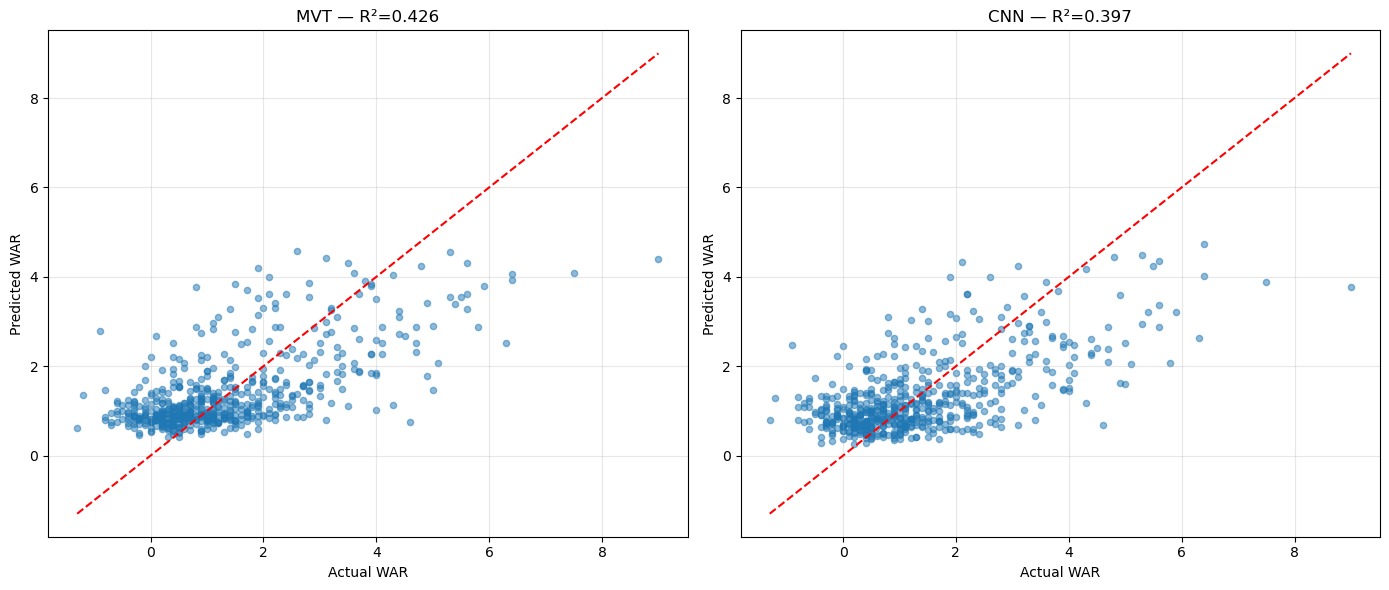

In [13]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['MVT (Transformer)', 'CNN'],
    'WAR MSE': [mvt_mse, cnn_mse],
    'WAR MAE': [mvt_mae, cnn_mae],
    'WAR R²': [mvt_r2, cnn_r2],
})
print(comparison.to_string(index=False))

winner = 'MVT' if mvt_mse < cnn_mse else 'CNN'
print(f'\nWinner (lowest WAR MSE): {winner}')

# Scatter plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(mvt_war_actuals, mvt_war_preds, alpha=0.5, s=20)
lims = [min(mvt_war_actuals.min(), mvt_war_preds.min()), max(mvt_war_actuals.max(), mvt_war_preds.max())]
axes[0].plot(lims, lims, 'r--')
axes[0].set_xlabel('Actual WAR')
axes[0].set_ylabel('Predicted WAR')
axes[0].set_title(f'MVT — R²={mvt_r2:.3f}')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(cnn_war_actuals, cnn_war_preds, alpha=0.5, s=20)
lims = [min(cnn_war_actuals.min(), cnn_war_preds.min()), max(cnn_war_actuals.max(), cnn_war_preds.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual WAR')
axes[1].set_ylabel('Predicted WAR')
axes[1].set_title(f'CNN — R²={cnn_r2:.3f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Pick the winner
if mvt_mse <= cnn_mse:
    best_model = best_mvt_model
    best_type = 'MVT'
    best_params = mvt_study.best_params
    best_metrics = {'mse': mvt_mse, 'mae': mvt_mae, 'r2': mvt_r2}
    best_scaler = mvt_scaler
else:
    best_model = best_cnn_model
    best_type = 'CNN'
    best_params = cnn_study.best_params
    best_metrics = {'mse': cnn_mse, 'mae': cnn_mae, 'r2': cnn_r2}
    best_scaler = cnn_scaler

# Save model weights
torch.save(best_model.state_dict(), os.path.join(RESULTS_DIR, 'best_model.pt'))

# Save scaler
with open(os.path.join(RESULTS_DIR, 'scaler.pkl'), 'wb') as f:
    pickle.dump(best_scaler, f)

# Save metadata
metadata = {
    'model_type': best_type,
    'hyperparameters': {k: (float(v) if isinstance(v, (np.floating, float)) else int(v) if isinstance(v, (np.integer, int)) else v) for k, v in best_params.items()},
    'metrics': {k: float(v) for k, v in best_metrics.items()},
}
if best_type == 'MVT':
    metadata['feature_stats'] = mvt_feat_stats
    metadata['war_mean'] = mvt_war_mean
    metadata['war_std'] = mvt_war_std

with open(os.path.join(RESULTS_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Saved {best_type} model to {RESULTS_DIR}')
print(f'  best_model.pt, scaler.pkl, metadata.json')
print(f'  Metrics: MSE={best_metrics["mse"]:.4f}, MAE={best_metrics["mae"]:.4f}, R²={best_metrics["r2"]:.4f}')

Saved MVT model to ./results/pitcher_model/
  best_model.pt, scaler.pkl, metadata.json
  Metrics: MSE=1.2176, MAE=0.8552, R²=0.4260
